In [1]:
import sys
import os

# 1. Rileva se l'esecuzione avviene su Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("⚡ Esecuzione su Google Colab.")
    from google.colab import drive
    drive.mount('/content/drive')
    
    # URL del tuo repository GitHub e percorso in Colab
    REPO_URL = "https://github.com/giacomosalvatori03/3D_Perception.git"
    REPO_DIR = "/content/3D_Perception"
    
    # Se la repo non è ancora presente su Colab la clona, altrimenti scarica gli aggiornamenti
    if not os.path.exists(REPO_DIR):
        print("📥 Clonazione del repository da GitHub...")
        !git clone {REPO_URL} {REPO_DIR}
    else:
        print("🔄 Aggiornamento del codice da GitHub...")
        %cd {REPO_DIR}
        !git pull
        
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
        
    # PERCORSO DEL DATASET SU GOOGLE DRIVE
    # Modifica questo percorso con la posizione esatta della cartella 'kitti_validation' sul tuo Drive
    DATASET_PATH = "/content/drive/MyDrive/3D_Perception/data/kitti_validation"

else:
    print("💻 Esecuzione in Locale.")
    PROJECT_ROOT = os.path.abspath('..')
    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    DATASET_PATH = os.path.join(PROJECT_ROOT, 'data/kitti_validation')

print(f"✅ Directory corrente: {os.getcwd()}")
print(f"✅ Dataset Path: {DATASET_PATH}")

Mounted at /content/drive
📥 Clonazione del repository da GitHub...
Cloning into '/content/3D_Perception'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (168/168), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 168 (delta 80), reused 142 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (168/168), 1.88 MiB | 3.71 MiB/s, done.
Resolving deltas: 100% (80/80), done.
✅ Directory corrente: /content/3D_Perception
✅ Dataset Path: /content/drive/MyDrive/3D_Perception/data/kitti_validation


In [2]:
from src import KittiDataset
from src.detectors.pillarization import Pillarizer

# Carica il primo sample dal dataset
dataset = KittiDataset(data_root=DATASET_PATH)
sample = dataset[0]
points = sample['points']

# Inizializza il Pillarizer
pillarizer = Pillarizer()
features, coords = pillarizer.process(points)

print(f"Punti LiDAR iniziali: {points.shape}")
print(f"Pillars estratti (P, MaxPoints, Features): {features.shape}")
print(f"Coordinate dei Pillars (P, [batch, y, x]): {coords.shape}")

📦 KittiDataset caricato da '/content/drive/MyDrive/3D_Perception/data/kitti_validation' (/content/drive/MyDrive/3D_Perception/data/kitti_validation/velodyne_reduced): 3769 campioni trovati.
Punti LiDAR iniziali: (18630, 4)
Pillars estratti (P, MaxPoints, Features): torch.Size([6815, 32, 9])
Coordinate dei Pillars (P, [batch, y, x]): torch.Size([6815, 3])


In [2]:
from src import KittiDataset, LidarDetector

# Inizializza dataset e detector
dataset = KittiDataset(data_root=DATASET_PATH)
detector = LidarDetector(max_distance=70.0)

# Esegui la detection su un sample
sample = dataset[0]
detections = detector.detect(sample)
print(f"Predizioni generate: {len(detections)}")

⚙️ LidarDetector inizializzato su device: cuda
✅ Pesi PointPillars gia presenti in: weights/pointpillar_kitti.pth
📦 Caricamento checkpoint PyTorch da: weights/pointpillar_kitti.pth
✅ Checkpoint PointPillars caricato con successo in memoria!
Predizioni generate: 0


In [4]:
import os
import torch
from scripts.pointpillar_weights import download_pointpillars_weights

# 1. Scarica i pesi (se non già presenti)
weights_path = download_pointpillars_weights()

# 2. Verifica l'esistenza e la dimensione del file
if os.path.exists(weights_path):
    file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)
    print(f"📁 File trovato: {weights_path} ({file_size_mb:.2f} MB)")

    # 3. Carica il checkpoint con PyTorch
    print("⏳ Caricamento del checkpoint con torch.load()...")
    checkpoint = torch.load(weights_path, map_location='cpu')
    
    # 4. Ispeziona la struttura del file .pth
    print("\n✅ Checkpoint caricato con successo!")
    print(f"🔑 Chiavi principali del file: {list(checkpoint.keys())}")
    
    # Estraggo lo state_dict (i pesi reali dei layer della rete neurale)
    state_dict = checkpoint.get('state_dict', checkpoint)
    print(f"🧠 Numero totale di layer/parametri nella rete: {len(state_dict)}")
    
    # Mostra i primi 5 layer per conferma
    print("\nEsempio dei primi layer trovati:")
    for i, (key, value) in enumerate(state_dict.items()):
        if i >= 5:
            break
        print(f"  • {key}: shape {value.shape}")
else:
    print("❌ File dei pesi non trovato.")

✅ Pesi PointPillars gia presenti in: weights/pointpillar_kitti.pth
📁 File trovato: weights/pointpillar_kitti.pth (18.52 MB)
⏳ Caricamento del checkpoint con torch.load()...

✅ Checkpoint caricato con successo!
🔑 Chiavi principali del file: ['meta', 'state_dict']
🧠 Numero totale di layer/parametri nella rete: 126

Esempio dei primi layer trovati:
  • backbone.blocks.0.0.weight: shape torch.Size([64, 64, 3, 3])
  • backbone.blocks.0.1.weight: shape torch.Size([64])
  • backbone.blocks.0.1.bias: shape torch.Size([64])
  • backbone.blocks.0.1.running_mean: shape torch.Size([64])
  • backbone.blocks.0.1.running_var: shape torch.Size([64])


In [3]:
from src import KittiDataset, LidarDetector

# Inizializzazione detector
detector = LidarDetector()

# Esecuzione su un sample di test
dataset = KittiDataset(data_root=DATASET_PATH)
sample = dataset[0]
detections = detector.detect(sample)

⚙️ LidarDetector inizializzato su device: cuda
✅ Pesi PointPillars gia presenti in: weights/pointpillar_kitti.pth
📦 Caricamento checkpoint PyTorch da: weights/pointpillar_kitti.pth
✅ Checkpoint PointPillars caricato con successo in memoria!


In [2]:
from src import KittiDataset
dataset = KittiDataset(data_root=DATASET_PATH)

sample = dataset[0]
print(f"Sample ID: {sample['sample_id']}")
print(f"Numero di oggetti GT caricati: {len(sample['labels'])}")
if len(sample['labels']) > 0:
    print(f"Primo oggetto GT: {sample['labels'][0]}")

Sample ID: 000001
Numero di oggetti GT caricati: 3
Primo oggetto GT: {'type': 'Truck', 'truncation': 0.0, 'occlusion': 0, 'alpha': -1.57, 'bbox_2d': array([599.41, 156.4 , 629.75, 189.25], dtype=float32), 'dimensions_3d': array([ 2.85,  2.63, 12.34], dtype=float32), 'location_3d': array([ 0.47,  1.49, 69.44], dtype=float32), 'rotation_y': -1.56}


⚙️ LidarDetector inizializzato su device: cuda
⬇️ Scaricamento pesi PointPillars pre-addestrati (~20 MB)...
🎉 Download completato con successo: weights/pointpillar_kitti.pth
📦 Caricamento checkpoint PyTorch da: weights/pointpillar_kitti.pth
✅ Checkpoint PointPillars caricato con successo in memoria!
🎉 Pipeline completata con successo! Oggetti 3D rilevati: 457


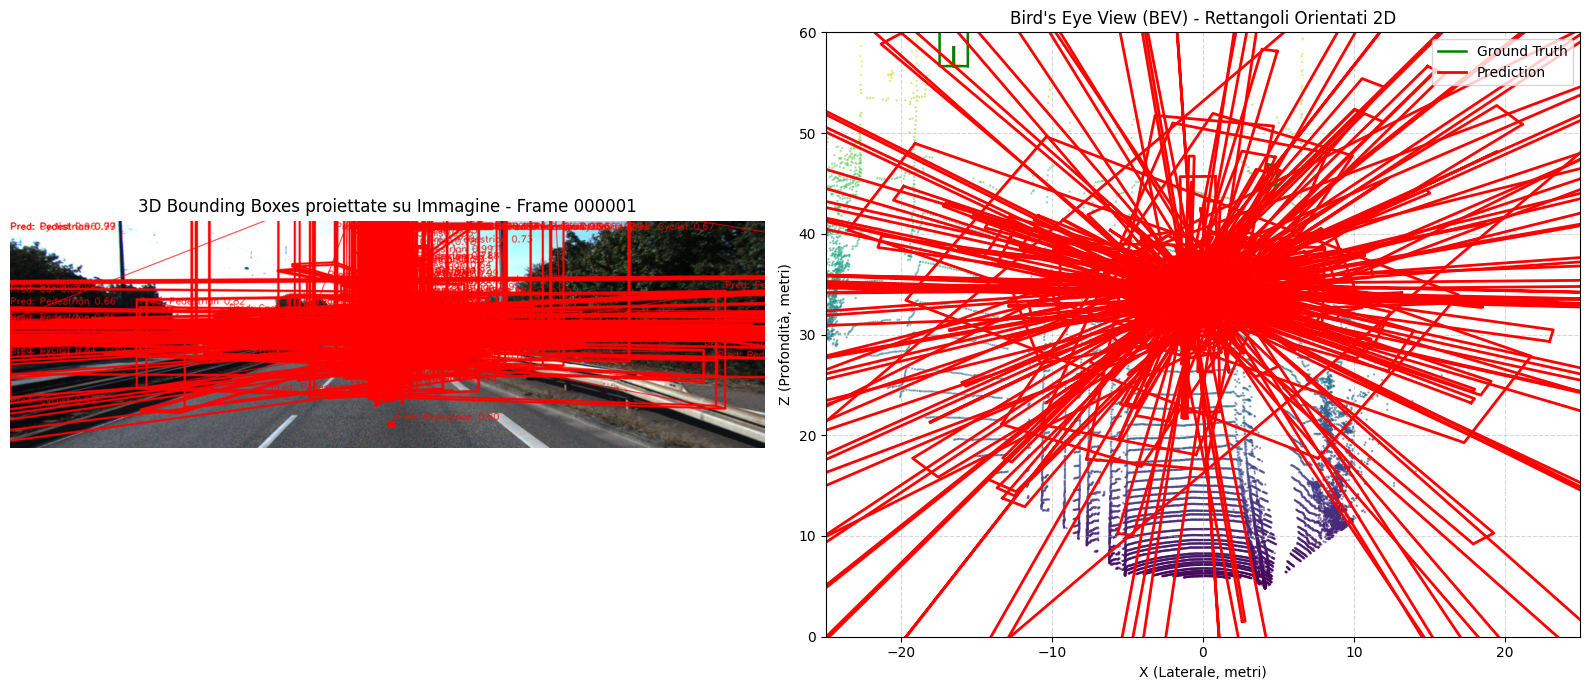

In [3]:
from src import KittiDataset, LidarDetector, Visualizer

# Carica il dataset e il detector
dataset = KittiDataset(data_root=DATASET_PATH)
detector = LidarDetector(conf_threshold=0.3)

# Seleziona un sample di test
sample = dataset[0]

# Genera le predizioni 3D reali con PointPillars
detections = detector.detect(sample)
print(f"🎉 Pipeline completata con successo! Oggetti 3D rilevati: {len(detections)}")

# Visualizza la scena con i box Ground Truth (Verdi) e le Predizioni PointPillars (Rosse)
Visualizer.visualize_scene(sample, predictions=detections, draw_gt=True)

In [4]:
import torch

# 1. Verifica quanti pesi del checkpoint sono stati caricati e quanti sono rimasti casuali
checkpoint = torch.load("weights/pointpillar_kitti.pth", map_location=detector.device)
state_dict = checkpoint.get('state_dict', checkpoint)

model_keys = set(detector.net.state_dict().keys())
ckpt_keys = set(state_dict.keys())

print(f"🔑 Chiavi totali nel Checkpoint OpenMMLab: {len(ckpt_keys)}")
print(f"🧠 Layer totali della nostra PointPillarsNet: {len(model_keys)}")

# 2. Verifica dei punteggi grezzi di output della rete
sample = dataset[0]
inputs = detector._preprocess(sample['points'])

with torch.no_grad():
    cls_preds, box_preds = detector.net(inputs['pillar_features'], inputs['pillar_coords'])

scores = torch.sigmoid(cls_preds)
print("\n🔍 Controllo Output Rete Neurale:")
print(f" • cls_preds shape: {cls_preds.shape}")
print(f" • box_preds shape: {box_preds.shape}")
print(f" • Score Minimo: {scores.min().item():.4f} | Score Massimo: {scores.max().item():.4f}")
print(f" • Bounding Box con score > 0.3: {(scores > 0.3).sum().item()}")

🔑 Chiavi totali nel Checkpoint OpenMMLab: 126
🧠 Layer totali della nostra PointPillarsNet: 46

🔍 Controllo Output Rete Neurale:
 • cls_preds shape: torch.Size([1, 18, 248, 216])
 • box_preds shape: torch.Size([1, 42, 248, 216])
 • Score Minimo: 0.0002 | Score Massimo: 0.9978
 • Bounding Box con score > 0.3: 937371
